
# A/B Testing & Uplift Modeling for Marketing Campaigns

This notebook demonstrates how to analyze a randomized marketing experiment (**A/B test**) and build an **uplift model** to target customers who benefit most from the campaign.

**You will see:**
1) Load & preview dataset  
2) A/B test analysis (conversion rates, lift, statistical significance, confidence intervals)  
3) Uplift modeling (T-learner) and scoring  
4) Uplift/Qini curves & decile table  
5) Clear, business-friendly summary


In [1]:

# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Metrics helpers
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6,4)  # single, readable plots


In [4]:

# 2) Load & preview dataset
csv_path = "synthetic_marketing_ab_uplift.csv"  # update path if needed
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head(10))
print("\nColumns:", list(df.columns))
print("\nMissing values per column:\n", df.isna().sum())


Shape: (5000, 9)


,customer_id,age,gender,loyalty_score,previous_purchases,income_bracket,treatment,conversion,spend
0,1,56,Female,80,2,Medium,1,0,0.00
1,2,69,Male,93,2,Medium,0,1,29.38
2,3,46,Female,6,1,Low,1,0,0.00
3,4,32,Male,26,0,Medium,1,0,0.00
4,5,60,Female,75,1,Low,0,0,0.00
5,6,25,Female,88,2,Medium,1,0,0.00
6,7,38,Male,93,1,Low,0,0,0.00
7,8,56,Male,3,0,Medium,0,0,0.00
8,9,36,Male,52,0,Medium,1,0,0.00
9,10,40,Male,74,0,High,0,0,0.00



Columns: ['customer_id', 'age', 'gender', 'loyalty_score', 'previous_purchases', 'income_bracket', 'treatment', 'conversion', 'spend']

Missing values per column:
 customer_id           0
age                   0
gender                0
loyalty_score         0
previous_purchases    0
income_bracket        0
treatment             0
conversion            0
spend                 0
dtype: int64


In [5]:

# 3) Sanity checks: randomization & base rates
print("Treatment split:\n", df['treatment'].value_counts(normalize=True).round(3))
print("\nOverall conversion rate:", df['conversion'].mean().round(4))

# Group-level conversion
group_conv = df.groupby('treatment')['conversion'].mean().rename({0: 'control', 1: 'treatment'})
print("\nConversion by group:")
print(group_conv)


Treatment split:
 treatment
0    0.5
1    0.5
Name: proportion, dtype: float64

Overall conversion rate: 0.1052

Conversion by group:
treatment
control      0.077969
treatment    0.132453
Name: conversion, dtype: float64


In [6]:

# 4) A/B Test: lift, p-value, and confidence intervals (two-proportion z-test)

def two_proportion_z_test(success_a, size_a, success_b, size_b):
    # A: control, B: treatment (common naming)
    p_a = success_a / size_a
    p_b = success_b / size_b
    p_pool = (success_a + success_b) / (size_a + size_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))
    z = (p_b - p_a) / se
    # two-sided p-value
    from math import erf, sqrt
    pval = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))
    return z, pval

# Counts
conv_control = df.loc[df.treatment == 0, 'conversion']
conv_treat = df.loc[df.treatment == 1, 'conversion']

success_control = int(conv_control.sum())
success_treat = int(conv_treat.sum())
n_control = conv_control.shape[0]
n_treat = conv_treat.shape[0]

rate_control = success_control / n_control
rate_treat = success_treat / n_treat
abs_lift = rate_treat - rate_control
rel_lift = abs_lift / rate_control if rate_control > 0 else np.nan

# z-test
z, pval = two_proportion_z_test(success_control, n_control, success_treat, n_treat)

# 95% CI for difference using normal approximation
p_pool = (success_control + success_treat) / (n_control + n_treat)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_treat))
ci_low = abs_lift - 1.96 * se
ci_high = abs_lift + 1.96 * se

print("=== A/B Test Results ===")
print(f"Control: {success_control}/{n_control} = {rate_control:.4f}")
print(f"Treatment: {success_treat}/{n_treat} = {rate_treat:.4f}")
print(f"Absolute lift: {abs_lift:.4f}")
print(f"Relative lift: {rel_lift*100:.2f}%")
print(f"z = {z:.3f}, p-value = {pval:.5f}")
print(f"95% CI for lift: [{ci_low:.4f}, {ci_high:.4f}]")


=== A/B Test Results ===
Control: 195/2501 = 0.0780
Treatment: 331/2499 = 0.1325
Absolute lift: 0.0545
Relative lift: 69.88%
z = 6.278, p-value = 0.00000
95% CI for lift: [0.0375, 0.0715]


In [7]:

# 5) Features for uplift modeling
target = "conversion"
treat_col = "treatment"
id_col = "customer_id"

categorical = ["gender", "income_bracket"]
numeric = ["age", "loyalty_score", "previous_purchases"]

X = df[categorical + numeric + [treat_col]]
y = df[target].astype(int)

# We'll use a T-learner:
# - Fit model on treatment group to predict P(Y=1 | X, T=1)
# - Fit model on control group to predict P(Y=1 | X, T=0)
# - Uplift = p_treat_hat - p_control_hat

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical)
])

# Split to evaluate generalization (train uplift models on train split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [8]:

# 6) Fit T-Learner (two logistic regressions)
# Control model
ctrl_pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=500))])
ctrl_pipe.fit(X_train[X_train[treat_col] == 0].drop(columns=[treat_col]), y_train[X_train[treat_col] == 0])

# Treatment model
treat_pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=500))])
treat_pipe.fit(X_train[X_train[treat_col] == 1].drop(columns=[treat_col]), y_train[X_train[treat_col] == 1])

# Predict uplift on test
p_treat = treat_pipe.predict_proba(X_test.drop(columns=[treat_col]))[:, 1]
p_ctrl = ctrl_pipe.predict_proba(X_test.drop(columns=[treat_col]))[:, 1]
uplift_score = p_treat - p_ctrl

uplift_df = X_test.copy()
uplift_df["actual"] = y_test.values
uplift_df["uplift_score"] = uplift_score
uplift_df["p_treat_hat"] = p_treat
uplift_df["p_ctrl_hat"] = p_ctrl

display(uplift_df.head(10))


,gender,income_bracket,age,loyalty_score,previous_purchases,treatment,actual,uplift_score,p_treat_hat,p_ctrl_hat
4856,Female,Medium,31,70,3,0,0,0.068983,0.148241,0.079257
1840,Male,Low,30,69,0,0,0,0.100707,0.162127,0.061421
636,Male,Medium,66,51,0,1,0,0.037948,0.139755,0.101807
923,Female,Medium,48,77,1,1,0,0.054545,0.156095,0.101551
1602,Female,High,25,19,1,1,0,0.013024,0.078821,0.065797
1533,Female,Medium,18,91,6,0,0,0.122431,0.185724,0.063292
3783,Female,Medium,37,9,1,1,0,-0.005493,0.078865,0.084358
1427,Male,High,54,73,2,1,0,0.086489,0.160529,0.074040
790,Female,High,30,65,2,0,0,0.057396,0.127358,0.069962
3243,Male,Low,33,49,3,1,0,0.085752,0.139266,0.053514


,quantile,n,treat_rate,control_rate,uplift
0,1,150,0.139241,0.126761,0.012480
1,2,150,0.131579,0.054054,0.077525
2,3,150,0.150000,0.057143,0.092857
3,4,150,0.157143,0.100000,0.057143
4,5,150,0.140845,0.063291,0.077554
5,6,150,0.132353,0.085366,0.046987
6,7,150,0.076923,0.094118,-0.017195
7,8,150,0.074074,0.072464,0.001610
8,9,150,0.185714,0.075000,0.110714
9,10,150,0.122222,0.066667,0.055556


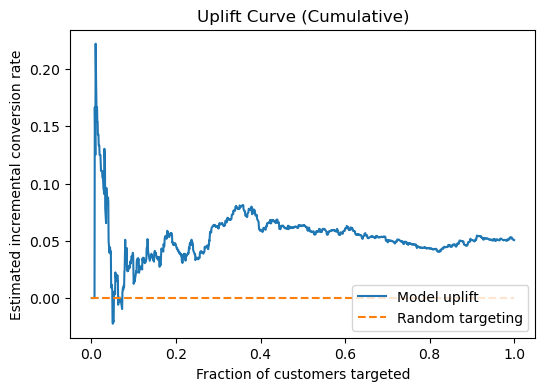

Approximate Qini (area under uplift curve vs baseline): 0.0527


In [14]:
# Merge back actual treatment and outcome for test set (no join needed)
eval_df = uplift_df.copy()
eval_df["treat_eval"] = X_test[treat_col].values
eval_df["y_eval"] = y_test.values

# Compute decile table
decile_table = uplift_by_quantile(eval_df, "uplift_score", "treat_eval", "y_eval", q=10)
display(decile_table)

# Uplift curve (cumulative)
def cumulative_uplift_curve(df, score_col, treat_col, outcome_col):
    df = df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    cum_treat = (df[treat_col] == 1).cumsum()
    cum_control = (df[treat_col] == 0).cumsum()
    cum_out_treat = ((df[treat_col] == 1) & (df[outcome_col] == 1)).cumsum()
    cum_out_ctrl = ((df[treat_col] == 0) & (df[outcome_col] == 1)).cumsum()

    adj_gain = []
    for i in range(len(df)):
        t_n = cum_treat.iloc[i]
        c_n = cum_control.iloc[i]
        t_y = cum_out_treat.iloc[i]
        c_y = cum_out_ctrl.iloc[i]
        t_rate = t_y / t_n if t_n > 0 else 0.0
        c_rate = c_y / c_n if c_n > 0 else 0.0
        adj_gain.append(t_rate - c_rate)

    x = np.arange(1, len(df)+1) / len(df)  # fraction targeted
    return x, np.array(adj_gain)

x, cu = cumulative_uplift_curve(eval_df, "uplift_score", "treat_eval", "y_eval")

plt.figure()
plt.plot(x, cu, label="Model uplift")
plt.plot([0,1],[0,0], '--', label="Random targeting")
plt.xlabel("Fraction of customers targeted")
plt.ylabel("Estimated incremental conversion rate")
plt.title("Uplift Curve (Cumulative)")
plt.legend(loc="lower right")
plt.show()

qini = np.trapz(cu, x)
print(f"Approximate Qini (area under uplift curve vs baseline): {qini:.4f}")


In [15]:

# 8) Business-friendly summary

# A/B results already computed above
print("==== Business Summary ====")
print("1) A/B Test")
print(f"- Control conversion: {rate_control:.3%}  (n={n_control})")
print(f"- Treatment conversion: {rate_treat:.3%} (n={n_treat})")
print(f"- Absolute lift: {abs_lift:.2%} (95% CI: {ci_low:.2%} to {ci_high:.2%})")
sig = "statistically significant" if pval < 0.05 else "not statistically significant"
print(f"- p-value: {pval:.4f} → Result is {sig}.")

print("\n2) Uplift Modeling")
top_deciles = decile_table.sort_values("quantile").head(3)
avg_uplift_top3 = top_deciles["uplift"].mean()
print(f"- Top 3 deciles by predicted uplift show an average measured uplift of {avg_uplift_top3:.2%}.")
print("- Target these segments first to maximize incremental conversions.")
print("- Use the uplift curve to choose how many customers to target given budget constraints.")


==== Business Summary ====
1) A/B Test
- Control conversion: 7.797%  (n=2501)
- Treatment conversion: 13.245% (n=2499)
- Absolute lift: 5.45% (95% CI: 3.75% to 7.15%)
- p-value: 0.0000 → Result is statistically significant.

2) Uplift Modeling
- Top 3 deciles by predicted uplift show an average measured uplift of 6.10%.
- Target these segments first to maximize incremental conversions.
- Use the uplift curve to choose how many customers to target given budget constraints.
